# 'Growth and Fund Structures': Public-Data Robustness Check

### Constantinos Kardaras; Hyeng Keun Koo; Johannes Ruf
### August 2026

This notebook provides a fully public implementation of the empirical analysis in
*Growth and Fund Structures* using the daily Fama--French market and risk-free
returns.

The main empirical analysis in the paper uses the CRSP S&P 500 series. Since
the Fama--French market portfolio represents a broader US equity portfolio,
the results in this notebook should be interpreted as a public-data robustness
check rather than as an exact replication of the CRSP results.

The notebook implements the same estimation, shrinkage, portfolio construction,
and performance calculations as in the main empirical analysis. Strategies are
rebalanced daily and transaction costs are not included.

Note that the discounted return constructed below is $(1+r^M_t)/(1+r^f_t)-1$, and hence
differs slightly from the Fama--French excess return $r^M_t-r^f_t$.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

## Getting data

In [2]:
FF_URL = (
    'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
    'F-F_Research_Data_Factors_daily_CSV.zip'
)

ff = pd.read_csv(
    FF_URL,
    compression='zip',
    skiprows=4,
    index_col=0
)

# Remove the non-data rows at the end of the file
ff = ff[ff.index.str.fullmatch(r'\d{8}')]

ff.index = pd.to_datetime(ff.index, format='%Y%m%d')
ff = ff.apply(pd.to_numeric, errors='coerce') / 100

In [3]:
# Getting rid of data that were not available at the time when the paper was written
CUTOFF_DATE = '2025-12-31'
ff = ff.loc[:CUTOFF_DATE]

In [4]:
df_ff = pd.DataFrame(index=ff.index)

# Reconstruct the total market return
df_ff['market_ret'] = ff['Mkt-RF'] + ff['RF']
df_ff['rf'] = ff['RF']

# Exact daily discounted simple return
df_ff['disc_ret'] = (1 + df_ff['market_ret']) / (1 + df_ff['rf']) - 1

# Discounted market wealth and daily empirical counterparts of the continuous-time processes R and C
df_ff['W_disc'] = (1 + df_ff['disc_ret']).cumprod()
df_ff['R'] = df_ff['disc_ret'].cumsum()
df_ff['C'] = (df_ff['disc_ret']**2).cumsum()

In [5]:
df_ff.head(3)

,market_ret,rf,disc_ret,W_disc,R,C
1926-07-01,0.0010,0.0001,0.0009,1.000900,0.000900,8.098380e-07
1926-07-02,0.0046,0.0001,0.0045,1.005404,0.005399,2.105579e-05
1926-07-06,0.0018,0.0001,0.0017,1.007113,0.007099,2.394521e-05


In [6]:
df_ff.tail(3)

,market_ret,rf,disc_ret,W_disc,R,C
2025-12-29,-0.0039,0.0002,-0.004099,715.751597,8.097099,3.042503
2025-12-30,-0.0018,0.0002,-0.002000,714.320380,8.095099,3.042507
2025-12-31,-0.0074,0.0002,-0.007598,708.892631,8.087501,3.042565


## Auxiliary functions

In [7]:
def shrinkage_factor(nuhat, C):
    """
    Calculate shrinkage factor for one-fund model.
    """
    def shrink(x):
        tmp = np.sqrt(1 + x) + np.sqrt(x)
        return 1 - 3 / (1 + tmp**(2/3) + tmp**(-2/3))

    ψ = 27 / 8 * nuhat**2 * C
    return shrink(ψ)

In [8]:
def plot_panel(df, start_of_plot=0, ttitle='', filename=''):
    # Keep the information accumulated since July 1926,
    # but display/trade only from start_of_plot onward
    R = df['R'].iloc[start_of_plot:]
    C = df['C'].iloc[start_of_plot:]
    r = df['disc_ret'].iloc[start_of_plot:]

    nuhat = R / C
    sf = shrinkage_factor(nuhat, C)

    # Position chosen at date t is held over the following return
    pi_unshrunk = nuhat.shift(1).fillna(0)
    pi_shrunk = (nuhat * sf).shift(1).fillna(0)

    # Exact discounted wealth, normalised to one at first displayed date
    W_nuhat = (1 + r * pi_unshrunk).cumprod()
    W_nuhat_s = (1 + r * pi_shrunk).cumprod()
    W_disc = df['W_disc'].iloc[start_of_plot:] / df['W_disc'].iloc[start_of_plot]

    # Discrete approximation to maximal F-achievable growth
    F = 0.5 * (r**2 * pi_unshrunk**2).cumsum()

    fig, ax = plt.subplots(2, 2, figsize=(15, 12))

    ax[0, 0].plot(nuhat, 'b', label=r"$\hat{\theta}$", linewidth=1.5)
    ax[0, 0].plot(nuhat * sf, 'r', label=r"$a \hat{\theta}$", linewidth=1.5)
    ax[0, 0].set_title(r'Estimate of $\hat{\theta}$ in the Bayesian setting')
    ax[0, 0].legend(frameon=False)

    ax[1, 0].plot(sf, 'r', label=r"$a$", linewidth=1.5)
    ax[1, 0].set_title(r'Shrinkage factor $a$')
    ax[1, 0].legend(frameon=False)

    ax[0, 1].plot(np.log(W_nuhat), 'b', linewidth=1.5, label=r'Log-wealth, using $\hat{\theta}$')
    ax[0, 1].plot(np.log(W_nuhat_s), 'r', linewidth=1.5, label=r'Log-wealth, using $a \hat{\theta}$')
    ax[0, 1].plot(np.log(W_disc), 'k', linewidth=1.5, label=r'Log-market portfolio')
    ax[0, 1].plot(F, 'g', linewidth=1.5, label=r'Maximal $\mathcal{F}$-achievable growth $F$')
    ax[0, 1].set_title('Logarithm of wealth processes')
    ax[0, 1].legend(frameon=False, fontsize=9)

    ax[1, 1].plot(C, 'm', linewidth=1.5, label=r'$C_{ww}$')
    ax[1, 1].set_title(r'Integrated variance $C_{ww}$')
    ax[1, 1].legend(frameon=False)

    plt.suptitle(ttitle, fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if filename:
        import os
        os.makedirs('plots', exist_ok=True)
        fig.savefig(f'plots/{filename}.png')
        print(f"Plot saved as plots/{filename}.png")

In [9]:
def performance_statistics(df, start_of_plot=0):
    """
    Calculate performance statistics for the market, unshrunk,
    and shrunk portfolios.
    
    Returns and wealth are discounted unless stated otherwise.
    The nominal CAGR converts discounted wealth back to nominal wealth.
    Turnover is one-way turnover, accounting for the drift in the
    market exposure before rebalancing.
    """
    # Estimator and shrinkage factor
    R = df['R'].iloc[start_of_plot:]
    C = df['C'].iloc[start_of_plot:]

    nuhat = R / C
    sf = shrinkage_factor(nuhat, C)

    # Target market exposures
    pi = pd.DataFrame({
        r'Market': 1.0,
        r'Unshrunk': nuhat,
        r'Shrunk': nuhat * sf,
    }, index=nuhat.index)

    # The exposure chosen at t-1 is applied to the return at t
    r = df['disc_ret'].loc[pi.index]
    held = pi.shift(1).iloc[1:]
    r = r.iloc[1:]

    returns = held.mul(r, axis=0)

    # Discounted wealth, normalised to one at the start of trading
    initial_wealth = pd.DataFrame([np.ones(len(returns.columns))], index=[pi.index[0]], columns=returns.columns)
    wealth = pd.concat([initial_wealth, (1 + returns).cumprod()])

    years = (wealth.index[-1] - wealth.index[0]).days / 365.25

    # Convert discounted wealth back to nominal wealth
    rf_wealth = (1 + df['rf'].loc[wealth.index]).cumprod()
    rf_wealth /= rf_wealth.iloc[0]
    wealth_nominal = wealth.mul(rf_wealth, axis=0)

    # One-way turnover: amount traded in the market portfolio when
    # rebalancing from the post-return exposure to the new target
    pre_trade = held.mul(1 + r, axis=0) / (1 + held.mul(r, axis=0))
    turnover = (pi.loc[returns.index] - pre_trade).abs()

    # Daily approximation to maximal F-achievable growth
    F_terminal = 0.5 * (returns['Unshrunk']**2).sum()

    result = pd.DataFrame({
        r'Annualised discounted log growth, $T^{-1}\log X_\pi(T)$, (%)': 100 * np.log(wealth.iloc[-1]) / years,
        'Nominal CAGR (%)': 100 * (wealth_nominal.iloc[-1]**(1 / years) - 1),
        'Annualised volatility (%)': 100 * returns.std(ddof=1) * np.sqrt(252),
        'Sharpe ratio': returns.mean() / returns.std(ddof=1) * np.sqrt(252),
        'Maximum drawdown of discounted wealth (%)': 100 * (wealth / wealth.cummax() - 1).min(),
        r'Terminal discounted wealth, $X_\pi(T)$': wealth.iloc[-1],
        'Mean absolute market exposure': held.abs().mean(),
        'Annualised one-way turnover (%)': 100 * turnover.mean() * 252,
        r'Terminal log wealth minus $F$, $\log X_\pi(T)-F(T)$': np.log(wealth.iloc[-1]) - F_terminal,
    }).T

    return result

## Empirical results

In [10]:
idx_start_ff = 1000

df_ff.index[idx_start_ff]

Timestamp('1929-11-12 00:00:00')

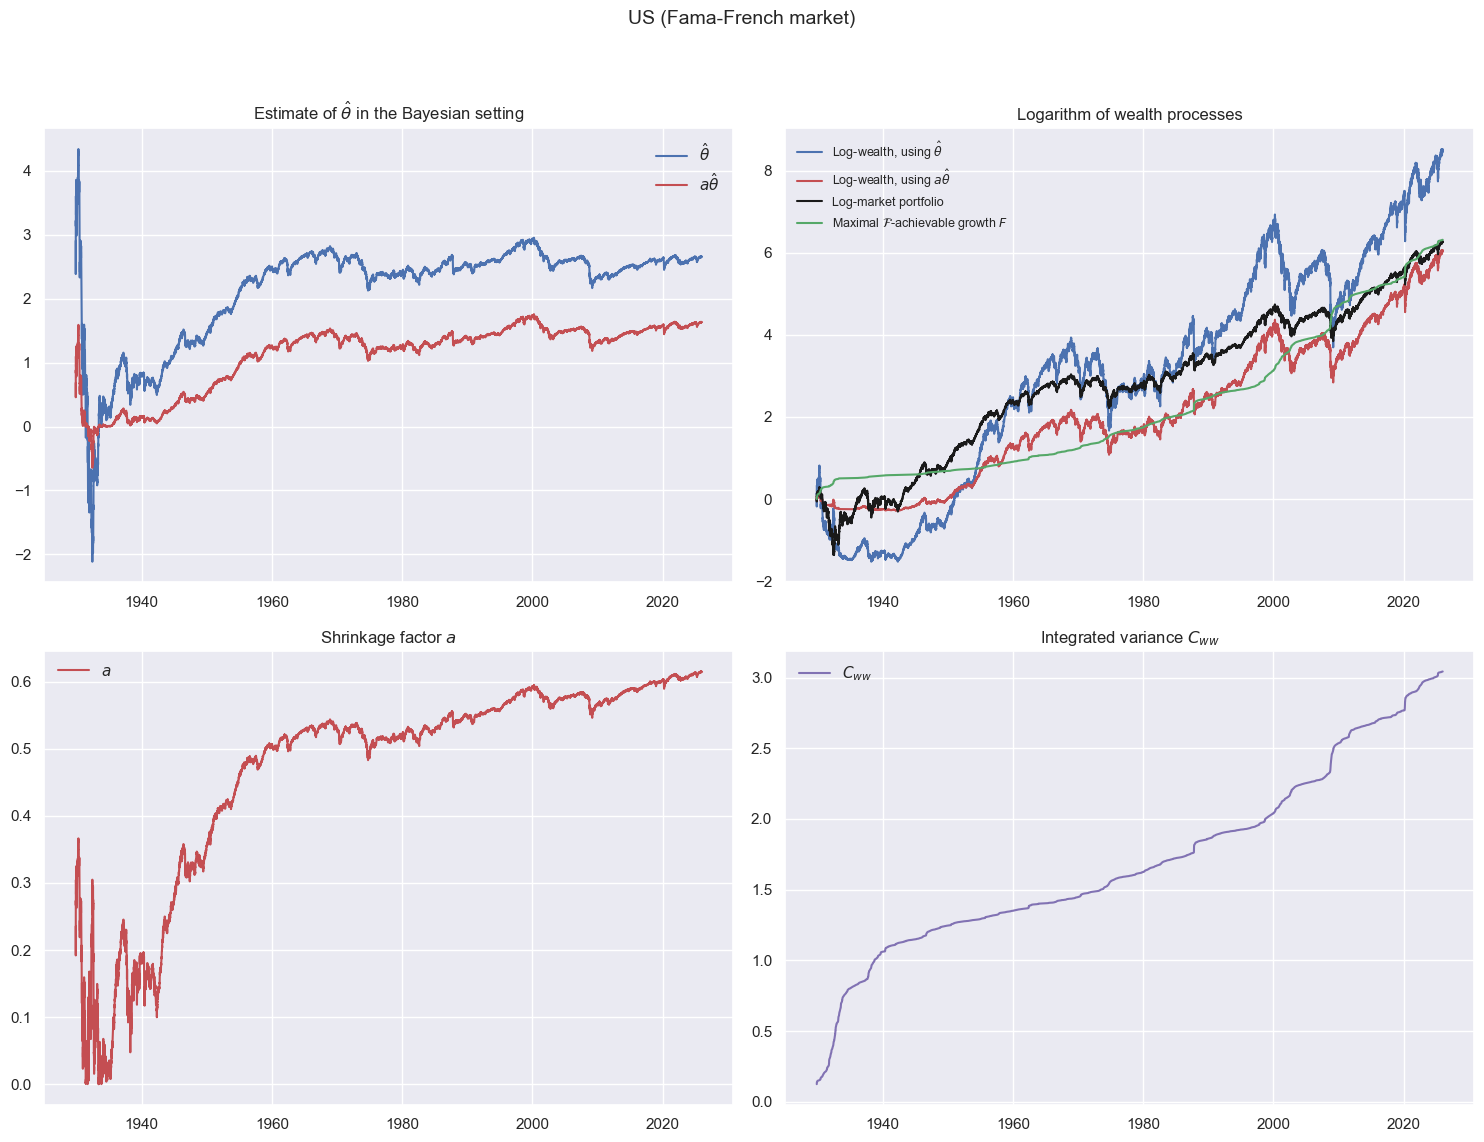

In [11]:
plot_panel(df_ff, start_of_plot=idx_start_ff, ttitle='US (Fama-French market)')

In [12]:
performance_ff = performance_statistics(df_ff, start_of_plot=idx_start_ff)
performance_ff.round(2)

,Market,Unshrunk,Shrunk
"Annualised discounted log growth, $T^{-1}\log X_\pi(T)$, (%)",6.52,8.83,6.28
Nominal CAGR (%),10.13,12.70,9.87
Annualised volatility (%),17.09,35.56,19.09
Sharpe ratio,0.45,0.42,0.41
Maximum drawdown of discounted wealth (%),-80.80,-96.06,-78.31
"Terminal discounted wealth, $X_\pi(T)$",525.93,4839.42,420.53
Mean absolute market exposure,1.00,2.13,1.09
Annualised one-way turnover (%),0.00,671.52,149.12
"Terminal log wealth minus $F$, $\log X_\pi(T)-F(T)$",-0.05,2.17,-0.27
